In [1]:
from rasterio.mask import mask
import rasterio
import geopandas as gpd
import numpy as np

In [3]:
tif_path = "data/GHS_BUILT_S_E2025_GLOBE_R2023A_54009_1000_V1_0.tif"
with rasterio.open(tif_path) as src:
     #We'll use this for all other rasters 
    target_crs = src.crs
    target_transform = src.transform
    target_width = src.width
    target_height = src.height
    
    boundary_cropto = gpd.read_file('data/world_adm0/adm0_asia_south.shp')
    # Ensure that both shape file and raster file has same CRS
    boundary_cropto = boundary_cropto.set_crs("EPSG:4326")
    boundary_cropto = boundary_cropto.to_crs(src.crs)

    out_image, out_transform = mask(src, boundary_cropto.geometry, crop=True)
    out_meta = src.meta.copy()
# Update metadata for the new clipped file
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

#Save the result
with rasterio.open("data/GHS-Southasia-2024.tif", "w", **out_meta) as dest:
    dest.write(out_image)

In [13]:
import rasterio
import geopandas as gpd
import numpy as np
from rasterio.mask import mask

tif_path = "data/GHS_BUILT_S_E2025_GLOBE_R2023A_54009_1000_V1_0.tif"

NODATA_IN = 4294967295
NODATA_OUT = -9999.0

with rasterio.open(tif_path) as src:

    boundary_cropto = gpd.read_file(
        "data/world_adm0/adm0_asia_south.shp"
    )

    boundary_cropto = boundary_cropto.set_crs("EPSG:4326")
    boundary_cropto = boundary_cropto.to_crs(src.crs)

    # Clip, explicitly preserving original NoData
    out_image, out_transform = mask(
        src,
        boundary_cropto.geometry,
        crop=True,
        nodata=NODATA_IN
    )

    out_meta = src.meta.copy()

# IMPORTANT: identify NoData while it is still uint32
nodata_mask = out_image == NODATA_IN

# Now convert to float32
out_image = out_image.astype(np.float32)

# Divide ONLY valid pixels
out_image[~nodata_mask] = out_image[~nodata_mask] / 10000.0

# Replace NoData with -9999
out_image[nodata_mask] = NODATA_OUT

# Metadata
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform,
    "dtype": "float32",
    "nodata": NODATA_OUT
})

with rasterio.open(
    "data/GHS-Southasia-2024.tif",
    "w",
    **out_meta
) as dest:
    dest.write(out_image)

In [18]:
!gdal_translate -of GTiff data/GHS-Southasia-2024.tif data/GHS-Southasia-2024-compressed.tif -co COMPRESS=DEFLATE -co TILED=YES -co PREDICTOR=2

Input file size is 3979, 3882
0...10...20...30...40...50...60...70...80...90...100 - done.


In [17]:
!gdalwarp \
  data/GHS-Southasia-2024.tif \
  data/GHS-Southasia-2024-4326-deflate.tif \
  -t_srs EPSG:4326 \
  -srcnodata -9999 \
  -dstnodata -9999 \
  -of GTiff \
  -co COMPRESS=DEFLATE \
  -co TILED=YES \
  -co PREDICTOR=2 \
  -co BIGTIFF=IF_SAFER \
  -multi

Creating output file that is 6768P x 4012L.
Processing data/GHS-Southasia-2024.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


In [16]:
!gdalwarp \
  data/GHS-Southasia-2024.tif \
  data/GHS-Southasia-2024-4326-zstd.tif \
  -t_srs EPSG:4326 \
  -srcnodata -9999 \
  -dstnodata -9999 \
  -of GTiff \
  -co COMPRESS=ZSTD \
  -co ZSTD_LEVEL=15 \
  -co TILED=YES \
  -co PREDICTOR=3 \
  -co BIGTIFF=IF_SAFER \
  -multi

Creating output file that is 6768P x 4012L.
Processing data/GHS-Southasia-2024.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


<Axes: >

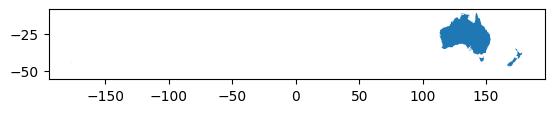

In [26]:
boundary = gpd.read_file('data/world_adm0_batch2/adm0_australia.shp')
boundary = boundary.set_crs("EPSG:4326")
boundary = boundary.simplify(0.01)
boundary.plot()

In [27]:
boundary.to_file('data/aus_boundary.geojson')

<Axes: >

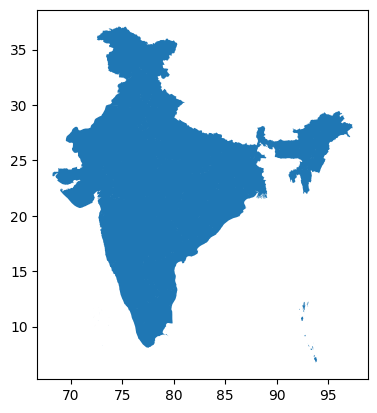

In [6]:
india = gpd.read_file('data/india_boundary.geojson')
india['c'] = 1
india = india.dissolve('c')
india.plot()

In [7]:
india['NAME'] = 'India'
india['GMI_CNTRY'] = 'IND'
india['REGION'] = 'Asia'
india

,geometry,NAME,GMI_CNTRY,REGION
c,,,,
1,"MULTIPOLYGON (((73.01822 8.27141, 73.01735 8.2...",India,IND,Asia


In [17]:
boundary = boundary.drop([3,5])
boundary

,NAME,GMI_CNTRY,REGION,geometry
0,Afghanistan,AFG,Asia,"POLYGON ((65.6273 37.3332, 65.64693 37.45888, ..."
1,Bangladesh,BGD,Asia,"MULTIPOLYGON (((90.64886 21.9911, 90.64636 22...."
2,Bhutan,BTN,Asia,"POLYGON ((88.75055 27.14727, 88.80635 27.25305..."
4,Nepal,NPL,Asia,"POLYGON ((80.85858 30.17471, 80.90414 30.21693..."
6,Sri Lanka,LKA,Asia,"POLYGON ((79.79344 7.59953, 79.75554 7.86583, ..."


In [19]:
import pandas as pd
boundary = gpd.GeoDataFrame(pd.concat([boundary,india]))

In [20]:
boundary.to_file('data/southasia_boundary.geojson')

# Loop

In [1]:
from glob import glob
from network_calculator import run_network_analysis

In [3]:
geojson_files = glob("data/gridextents/gridextents_kmlonly/*.kml")
geojson_files[:5]

['data/gridextents/gridextents_kmlonly/grids_agra.kml',
 'data/gridextents/gridextents_kmlonly/grids_ahmedabad.kml',
 'data/gridextents/gridextents_kmlonly/grids_akola.kml',
 'data/gridextents/gridextents_kmlonly/grids_allahabad.kml',
 'data/gridextents/gridextents_kmlonly/grids_alwar.kml']

In [38]:
# Paths to raster and csv
TIF_PATH = "data/landscan-india-2024-compressed.tif"
CSV_PATH = "data/cpcb_sites_202607.csv"

# Dictionary to store all results keyed by filename/region
airsheds = []
areas = []
pops = []
min_stations = []

active_monitors = []

avg_distances = []
avg_distance_scores = []

pop_pcts = []
pop_pct_scores = []

monitors_pcts = []
monitors_pct_scores = []

totalscores = []
for geojson_path in geojson_files:
    try:
        print(f"Processing: {geojson_path}...")

        airshed = geojson_path.split('grids_')[-1][:-4]
        airsheds.append(airshed)
        # Run analysis and save into dictionary
        res = run_network_analysis(
            geojson_path=geojson_path, tif_path=TIF_PATH, csv_path=CSV_PATH
        )

        areas.append(res['geography']['total_area_sq_km'])
        pops.append(res['geography']['total_population'])
        min_stations.append(res['network_requirements']['min_required_monitors'])

        active_monitors.append(res['network_metrics']['active_monitors_found'])
        
        avg_distances.append(res['network_metrics']['average_nearest_neighbor_dist_km'])
        avg_distance_scores.append(res['scoring']['score_distance'])

        pop_pcts.append(res['network_metrics']['population_represented_percent'])
        pop_pct_scores.append(res['scoring']['score_coverage'])

        monitors_pcts.append(res['network_metrics']['percent_of_required_monitors'])
        monitors_pct_scores.append(res['scoring']['score_required_pct'])

        totalscores.append(res['scoring']['total_score'])

    except Exception as e:
        print(f"Failed to process {geojson_path}: {e}")

Processing: data/gridextents/gridextents_kmlonly/grids_agra.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_ahmedabad.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_akola.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_allahabad.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_alwar.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_amravati.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_amritsar.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_anantapur.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_angul.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_anpara.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_asansol.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_aurangabad.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_balasore.kml...
Processing: data/gridextents/gridextents_kmlonly/grids_bangalore.kml...
Processing: data

In [41]:
import pandas as pd
df = pd.DataFrame([airsheds,areas, pops, min_stations,active_monitors, avg_distances,avg_distance_scores,
                   pop_pcts,pop_pct_scores, monitors_pcts,monitors_pct_scores,totalscores]).T

df.columns = ['airshed', 'area (sqkm)', 'population (M)','min_monitors_required','active_monitors',
              'avg_distance (km)','avg_distance_score',
              'population_covered','population_covered_score',
              'pct_required_monitors','pct_required_monitors_score','total_score'
             ]
df

,airshed,area (sqkm),population (M),min_monitors_required,active_monitors,avg_distance (km),avg_distance_score,population_covered,population_covered_score,pct_required_monitors,pct_required_monitors_score,total_score
0,agra,1759.52,3994783,39,6,4.89,5,29.84,3,15.38,1,9
1,ahmedabad,2843.23,8529800,72,13,4.78,5,25.2,3,18.06,1,9
2,akola,1040.95,843183,24,1,None,0,15.5,2,4.17,0,2
3,allahabad,1786.31,3897832,38,3,7.21,1,11.18,2,7.89,0,3
4,alwar,986.61,955795,23,1,None,0,16.52,2,4.35,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
99,vadodara,1029.56,2964700,40,2,15.8,1,9.67,1,5.0,0,2
100,varanasi,1788.53,4855772,41,4,4.67,5,10.91,2,9.76,0,7
101,vijayawada,2964.54,3435337,45,7,7.69,1,21.56,3,15.56,1,5
102,vishakhapatnam,2943.92,3133899,37,1,None,0,12.78,2,2.7,0,2


In [42]:
df['population (M)'] = df['population (M)'] /1000000

In [43]:
df

,airshed,area (sqkm),population (M),min_monitors_required,active_monitors,avg_distance (km),avg_distance_score,population_covered,population_covered_score,pct_required_monitors,pct_required_monitors_score,total_score
0,agra,1759.52,3.994783,39,6,4.89,5,29.84,3,15.38,1,9
1,ahmedabad,2843.23,8.5298,72,13,4.78,5,25.2,3,18.06,1,9
2,akola,1040.95,0.843183,24,1,None,0,15.5,2,4.17,0,2
3,allahabad,1786.31,3.897832,38,3,7.21,1,11.18,2,7.89,0,3
4,alwar,986.61,0.955795,23,1,None,0,16.52,2,4.35,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
99,vadodara,1029.56,2.9647,40,2,15.8,1,9.67,1,5.0,0,2
100,varanasi,1788.53,4.855772,41,4,4.67,5,10.91,2,9.76,0,7
101,vijayawada,2964.54,3.435337,45,7,7.69,1,21.56,3,15.56,1,5
102,vishakhapatnam,2943.92,3.133899,37,1,None,0,12.78,2,2.7,0,2


In [44]:
df.to_csv('airsheds_network_scores.csv',index=False)

In [37]:
min_stations

[39,
 39,
 72,
 72,
 24,
 24,
 38,
 38,
 23,
 23,
 25,
 25,
 37,
 37,
 24,
 24,
 34,
 34,
 33,
 33,
 44,
 44,
 41,
 41,
 22,
 22,
 77,
 77,
 33,
 33,
 44,
 44,
 39,
 39,
 41,
 41,
 23,
 23,
 74,
 74,
 27,
 27,
 37,
 37,
 125,
 125,
 24,
 24,
 43,
 43,
 24,
 24,
 23,
 23,
 32,
 32,
 22,
 22,
 31,
 31,
 31,
 31,
 23,
 23,
 41,
 41,
 37,
 37,
 39,
 39,
 38,
 38,
 81,
 81,
 83,
 83,
 40,
 40,
 45,
 45,
 37,
 37,
 23,
 23,
 23,
 23,
 34,
 34,
 38,
 38,
 37,
 37,
 42,
 42,
 25,
 25,
 33,
 33,
 40,
 40,
 36,
 36,
 22,
 22,
 31,
 31,
 25,
 25,
 46,
 46,
 93,
 93,
 29,
 29,
 39,
 39,
 22,
 22,
 23,
 23,
 61,
 61,
 38,
 38,
 34,
 34,
 34,
 34,
 32,
 32,
 110,
 110,
 33,
 33,
 34,
 34,
 45,
 45,
 27,
 27,
 24,
 24,
 28,
 28,
 41,
 41,
 25,
 25,
 23,
 23,
 25,
 25,
 22,
 22,
 22,
 22,
 44,
 44,
 63,
 63,
 71,
 71,
 32,
 32,
 42,
 42,
 34,
 34,
 38,
 38,
 42,
 42,
 24,
 24,
 36,
 36,
 24,
 24,
 26,
 26,
 35,
 35,
 37,
 37,
 21,
 21,
 36,
 36,
 20,
 20,
 64,
 64,
 23,
 23,
 33,
 33,
 36,
 36,
 40,
 

In [20]:
!gdal_translate -of GTiff data/pct_builtup_southasia.tif data/pct_builtup_southasia2024-compressed.tif -co COMPRESS=DEFLATE -co TILED=YES -co PREDICTOR=2

Input file size is 3979, 3882
0...10...20...30...40...50...60...70...80...90...100 - done.
